# 1. Gráficas de series de tiempo

Para realizar el pronóstico del nivel en la estación Calamar, se toman como variables explicativas los niveles de las estaciones Achí y El Banco, ubicadas en los ríos Cauca y Magdalena, respectivamente.

:::{figure} ./images/MapaEstaciones.png
:alt: Mapa de las estaciones
:width: 60%
:align: center

Figura 1. Mapa de las estaciones seleccionadas.
:::

## 1.1. Lectura de archivos de nivel

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import AutoMinorLocator

# Rutas y nombres de estaciones
estaciones = [
    ("Achi",r"C:\Users\Victus\Documents\Academico\MCT\Semestre2\MachineLearning\PF\DatosNivel\AchiNivelMedioDiarioCompleto.csv"),
    ("Calamar",r"C:\Users\Victus\Documents\Academico\MCT\Semestre2\MachineLearning\PF\DatosNivel\CalamarNivelMedioDiarioCompleto.csv"),
    ("El Banco",r"C:\Users\Victus\Documents\Academico\MCT\Semestre2\MachineLearning\PF\DatosNivel\ElBancoNivelMedioDiarioCompleto.csv")
]



## 1.2. Gráficas de series de tiempo de nivel

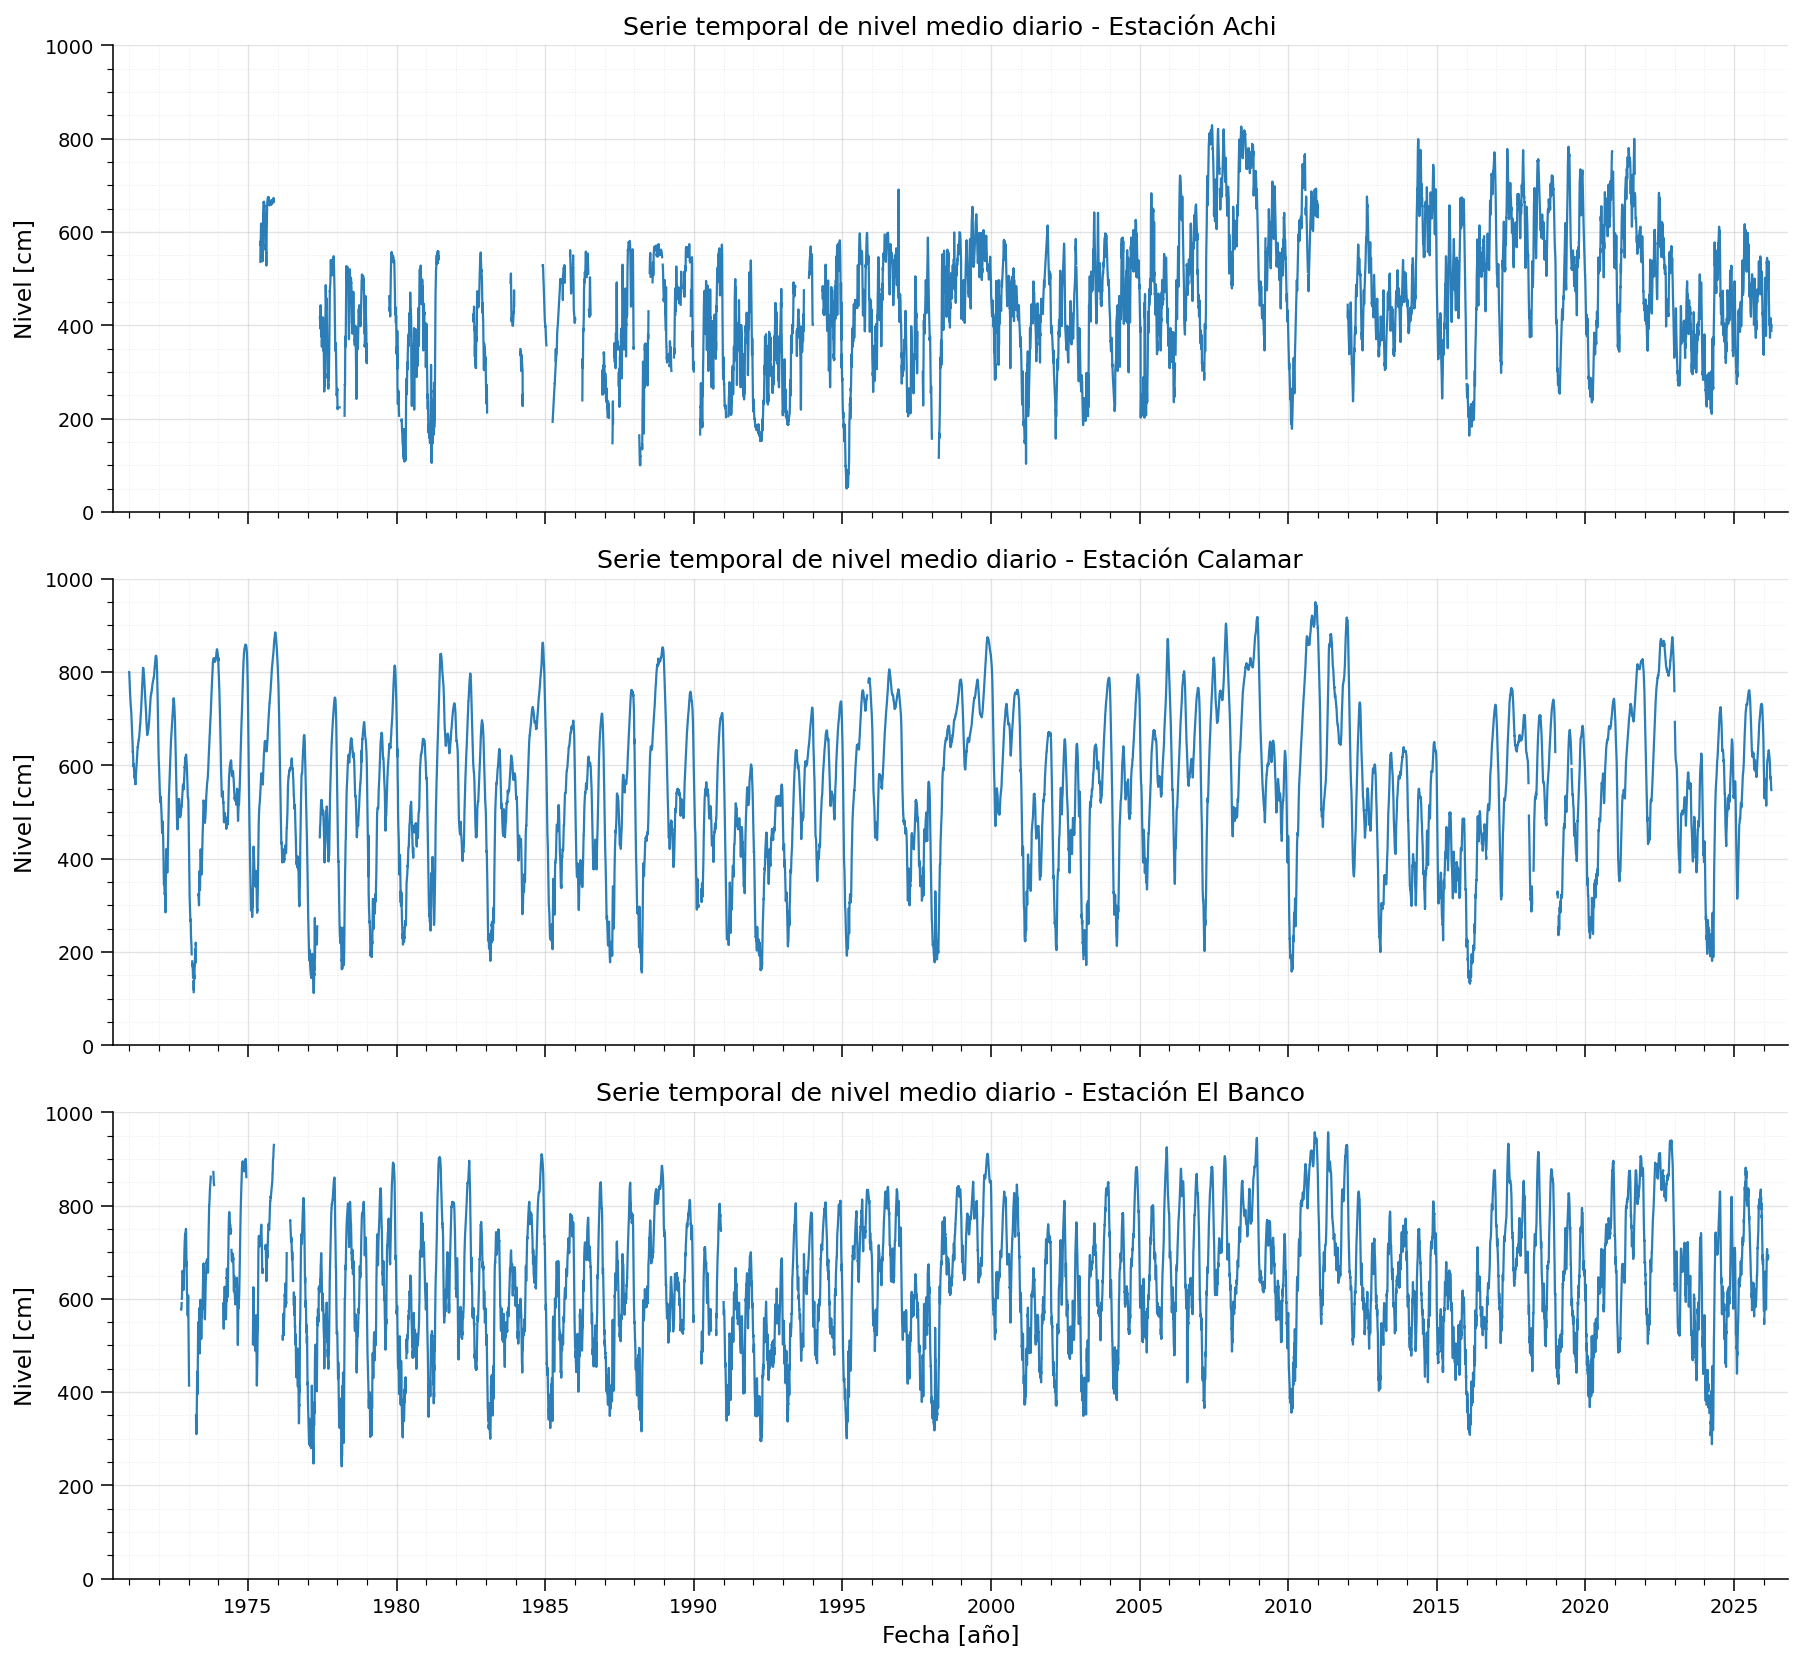

In [4]:

# Estilo general
plt.rcParams.update({
    "figure.figsize": (13, 12),
    "figure.dpi": 140,
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


# Crear figura con 3 subplots
fig, axes = plt.subplots(nrows=3, ncols=1, sharex=True)

for ax, (nombre, ruta) in zip(axes, estaciones):
    # Lectura
    df = pd.read_csv(ruta, parse_dates=["Fecha"])

    # Limpieza básica
    df["Fecha"] = pd.to_datetime(df["Fecha"], errors="coerce")
    df["Nivel"] = pd.to_numeric(df["Nivel"], errors="coerce")
    df = df.dropna(subset=["Fecha"]).sort_values("Fecha")

    # Gráfica
    ax.plot(
        df["Fecha"],
        df["Nivel"],
        lw=1.15,
        alpha=0.95,
        label="Nivel medio diario"
    )

    # Etiquetas
    ax.set_title(f"Serie temporal de nivel medio diario - Estación {nombre}")
    ax.set_ylabel("Nivel [cm]")
    ax.set_ylim(0, 1000)

    # Ticks de fecha
    ax.xaxis.set_major_locator(mdates.YearLocator(base=5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.YearLocator(base=1))

    # Ticks menores en Y
    ax.yaxis.set_minor_locator(AutoMinorLocator(4))

    # Grilla
    ax.grid(True, which="major", linestyle="-", linewidth=0.7, alpha=0.35)
    ax.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.25)

    # Acabados
    ax.tick_params(axis="both", which="major", length=6, width=0.8, direction="out")
    ax.tick_params(axis="both", which="minor", length=3, width=0.6, direction="out")
    ax.margins(x=0.01)
    # ax.legend(frameon=False, loc="upper right")

# Etiqueta común del eje x solo abajo
axes[-1].set_xlabel("Fecha [año]")

plt.tight_layout()
plt.show()
